# 2026-10-07 Orthogonal distance to KE01 BPT curves: PDFs by stage

Derived from `20261007_check_corrected_Halpha_surface_density_BPT_PDFs_by_stage.ipynb`; source unchanged. Show **NII first** (pre-peak, close-to-peak, post-peak), then **SII** in the same stage order. Six overlapping selections remain on every PDF:

- SF: usable disc, finite `LOGSFR_SURFACE_DENSITY_HII`, finite proxy EW(Halpha)>6 Angstrom, finite intrinsic Halpha dispersion <45 km/s.
- NSF: Balmer-detected usable disc outside SF.
- TNSF: NSF with `NII_BPT == 3` and `SII_BPT` in `{2, 3}` (LINER or Seyfert), in both diagrams.
- SF + EW(Halpha)>20; NSF + EW(Halpha)<3; TNSF + EW(Halpha)<3, all strict finite EW cuts.

Inherit inclination <80 degrees, unmasked finite-mass/gas-bin disc footprint, finite geometry, mass/gas WCS agreement and strict finite **`SNR_POSTFIT > 25`**. No additional radius, stellar-density or forbidden-line S/N cut. Corrected all-region fluxes define jointly finite positive ratios at the same spaxel. SII requires both doublet components finite and positive. NII and SII can therefore use different finite subsets. Missing/invalid products are reported in QC.

## Distance convention

Let $x=\log_{10}([\mathrm{NII}]/\mathrm{H}\alpha)$ or $\log_{10}(([\mathrm{SII}]6716+[\mathrm{SII}]6730)/\mathrm{H}\alpha)$, and $y=\log_{10}([\mathrm{OIII}]/\mathrm{H}\beta)$. Use the red KE01 curves from [Kewley et al. (2001), equations 5--6](https://arxiv.org/pdf/astro-ph/0106324):

$$f_{\mathrm{NII}}(u)=\frac{0.61}{u-0.47}+1.19,\quad u<0.47,$$
$$f_{\mathrm{SII}}(u)=\frac{0.72}{u-0.32}+1.30,\quad u<0.32.$$

The **orthogonal magnitude** is the global shortest Euclidean distance from **every selected finite BPT point, wherever it lies**, to the red KE01 demarcation curve in log-ratio space. Upper-right points are included, even when their observed $x$ is at or beyond the curve's vertical asymptote.

Here $(x,y)$ is the observed point, while $(u,f(u))$ is a candidate closest point on the red curve. The restriction $u<b$ describes the **target curve only** ($b=0.47$ for NII, $b=0.32$ for SII); it imposes **no restriction on the observed $x$ or $y$**. This target is sometimes called the hyperbola's left-hand branch. The separate algebraic branch at $u>b$ is not the red BPT demarcation curve used here.

$$|d_\perp|=\min_{u<b}\sqrt{(x-u)^2+[y-f(u)]^2}.$$

For each observed point, search the entire red demarcation curve for its nearest point, then measure the length of the connecting segment. Both axes have equal metric weight; units are dex in this two-dimensional log-ratio metric. This is a geometric diagnostic, with no uncertainty weighting. The target curve is not truncated at the plotting endpoints (-2 or 0.3), and observed points outside a conventional BPT window remain included. Far-tail distances extrapolate the analytical fit geometrically; they do not establish the physical validity of a classification there.

**Sign:** negative if $x<b$ and $y<f(x)$ (below/left side of the red curve); positive otherwise. Observed points with $x\ge b$ still receive their shortest distance to the red curve, with a positive sign; they are not discarded and their distance is not evaluated against the separate algebraic branch. Points on the red curve have zero distance. Positive distance does not by itself identify an excitation mechanism. The plotted x axis is the **signed distance itself**, on a linear axis, with a zero reference line; do not take its logarithm.

**Exact projection for any observed $(x,y)$:** writing the target red curve as $(u,v)=(b-t,c-a/t)$ with $t>0$, stationary squared distances obey

$$t^4+(x-b)t^3+a(c-y)t-a^2=0.$$

Find every positive real root and choose the global smallest distance. Since squared distance diverges as $t\to0^+$ and $t\to\infty$, a minimum is among those stationary points. Multiple local minima are possible; selecting only one optimizer root could fail. Identical ratio pairs are solved once for efficiency, then expanded back to every spaxel without changing weights. Verify the closest point lies on the branch and the displacement is perpendicular to its tangent.

**PDF convention:** pooled-spaxel probability density per dex; each nonempty curve integrates to one across the full finite range. Common full-range bins for each BPT version span all regions and stages; no clipping. Print counts, signed range, median and negative/positive fractions before each figure. Larger galaxy footprints carry more weight and spaxels sharing a gas bin are not independent spectra. Selections overlap; these are descriptive distributions, without propagated measurement errors or an evolutionary inference. Figures use `plt.show()` only; FITS products are unchanged.

**TNSF definition update (2026-10-08):** `NSF & (NII_BPT == 3) & np.isin(SII_BPT, [2, 3])`.
SII code 2 is LINER and code 3 is Seyfert; this joint requirement applies
to TNSF and all of its EW-restricted subsets in both BPT diagrams.
The existing SF, NSF, usable-disc footprint, strict SNR_POSTFIT cut,
support rules, and weighting conventions are retained.


In [1]:
from pathlib import Path
import hashlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy import units as u
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "v3tk_v7.6.8").is_dir():
    PROJECT_ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = ("{galid}_gas_bin_maps_further.fits", "{galid}_gas_BIN_maps_further.fits")
EW_FILE_PATTERNS = ("{galid}_proxy_EW_maps_further.fits", "{galid}_proxy_EW_maps.fits")
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"
MASS_HDU, BIN_HDU_MASS, BIN_HDU_GAS = "LOGMASS_SURFACE_DENSITY", "BINID", "BIN_ID"
SFR_HDU, EW_HDU = "LOGSFR_SURFACE_DENSITY_HII", "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU, HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA", "HA6562_SIGMA_CORR"
MASK_TABLE_HDU, MASK_COLUMN = "MASKFILE", "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"
EW_HA_MIN, HALPHA_SIGMA_MAX, SFH_SNR_POSTFIT_MIN = 6.0, 45.0, 25.0
I_MAX_PRIMARY, WCS_TOLERANCE_ARCSEC = 80.0, 0.05
BALMER_LINES = ("HB4861", "HA6562")
REASON_LABELS = ("BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
                 "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45")
CATEGORY_ORDER = ("SF", "NSF", "TNSF", "SF + EW(Halpha)>20", "NSF + EW(Halpha)<3", "TNSF + EW(Halpha)<3")
OBSERVABLE_ORDER = ("NII", "SII")
KE01_PARAMETERS = {"NII": (0.61, 0.47, 1.19), "SII": (0.72, 0.32, 1.30)}
PROJECTION_CHUNK_SIZE = 8192
N_HIST_BINS = 60
CATEGORY_COLORS = dict(zip(CATEGORY_ORDER, ("#2166ac", "#e08214", "#b2182b", "#2166ac", "#e08214", "#b2182b")))
CATEGORY_STYLES = dict(zip(CATEGORY_ORDER, ("-", "-", "-", "--", "--", "--")))
OBSERVABLE_LABELS = {d: rf"Signed orthogonal distance to KE01 ({d} BPT) [dex]" for d in OBSERVABLE_ORDER}
OBSERVABLE_TITLES = {d: d + " BPT signed orthogonal distance to KE01" for d in OBSERVABLE_ORDER}
mpl.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": False})
SOURCE_NOTEBOOK_SHA256 = "2a2b64fc16c73cc7885ef5867b838c47bd9077c77f28b608de74a0f497280958"
print("Source notebook SHA256:", SOURCE_NOTEBOOK_SHA256)
print("Signed shortest distance to KE01 left branch in equally weighted log-ratio space")


Source notebook SHA256: 2a2b64fc16c73cc7885ef5867b838c47bd9077c77f28b608de74a0f497280958
Signed shortest distance to KE01 left branch in equally weighted log-ratio space


## Inherited catalogue, geometry and selection helpers

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    tnsf = nsf & (nii == 3) & np.isin(sii, [2, 3])
    assert not np.any(tnsf & ~nsf)
    assert np.all(nii[tnsf] == 3)
    assert np.isin(sii[tnsf], [2, 3]).all()
    maps.update({
        "tnsf_mask": tnsf, "nii_bpt_class": nii, "sii_bpt_class": sii,
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": first_existing([folder / MASS_FILE_PATTERN.format(galid=galid)]),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": first_existing([folder / MASK_FILE_PATTERN.format(galid=galid)]),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)



## Global orthogonal projection helper

Solve all stationary roots on the full physical left-hand branch; use the minimum distance and verify tangent orthogonality.

In [4]:
def project_ke01_unique(pairs, diagram):
    """Global projection from all positive real stationary roots, in chunks."""
    a, b, c = KE01_PARAMETERS[diagram]
    signed = np.empty(len(pairs), dtype=float)
    closest = np.empty_like(pairs)
    max_residual = 0.0
    for start in range(0, len(pairs), PROJECTION_CHUNK_SIZE):
        part = pairs[start:start + PROJECTION_CHUNK_SIZE]
        x, y = part.T
        # Companion matrices of t^4 + (x-b)t^3 + a(c-y)t - a^2.
        companion = np.zeros((len(part), 4, 4), dtype=float)
        companion[:, 0, 0] = b - x
        companion[:, 0, 2] = a * (y - c)
        companion[:, 0, 3] = a * a
        companion[:, 1, 0] = companion[:, 2, 1] = companion[:, 3, 2] = 1.0
        roots = np.linalg.eigvals(companion)
        real_positive = ((np.abs(roots.imag) <= 1e-9 * np.maximum(1.0, np.abs(roots.real)))
                         & (roots.real > 0))
        if not real_positive.any(axis=1).all():
            raise ArithmeticError('No positive real stationary root')
        t = np.where(real_positive, roots.real, np.nan)
        u, v = b - t, c - a / t
        squared = (x[:, None] - u)**2 + (y[:, None] - v)**2
        squared = np.where(real_positive, squared, np.inf)
        best = np.argmin(squared, axis=1)
        indices = np.arange(len(part))
        tb = t[indices, best]
        ub, vb = u[indices, best], v[indices, best]
        magnitude = np.sqrt(squared[indices, best])
        # Normal = (a/t^2, 1); test orthogonality with unit tangent (1,-a/t^2).
        slope = -a / tb**2
        residual = np.abs(((x - ub) + (y - vb) * slope) / np.hypot(1.0, slope))
        relative = residual / np.maximum(1.0, magnitude)
        max_residual = max(max_residual, float(relative.max(initial=0)))
        assert np.all(relative < 1e-8), 'Projection is not perpendicular'
        assert np.all(tb > 0) and np.all(ub < b)
        assert np.allclose(vb, c - a / tb, atol=1e-12, rtol=1e-12)
        below = np.zeros(len(part), dtype=bool)
        left = x < b
        below[left] = y[left] < c + a / (x[left] - b)
        distances = np.where(below, -magnitude, magnitude)
        distances[magnitude < 1e-12] = 0.0
        signed[start:start + len(part)] = distances
        closest[start:start + len(part)] = np.column_stack((ub, vb))
    return signed, closest, max_residual

def signed_ke01_distance(x, y, selected, diagram):
    paired = selected & np.isfinite(x) & np.isfinite(y)
    result = np.full(x.shape, np.nan, dtype=float)
    pairs = np.column_stack((x[paired], y[paired]))
    if not len(pairs):
        return result, {'N_paired': 0, 'N_unique_pairs': 0, 'max_orthogonality_residual': 0.0}
    unique, inverse = np.unique(pairs, axis=0, return_inverse=True)
    distances, _, residual = project_ke01_unique(unique, diagram)
    assert np.isfinite(distances).all()
    result[paired] = distances[inverse]
    assert np.array_equal(np.isfinite(result), paired)
    return result, {'N_paired': len(pairs), 'N_unique_pairs': len(unique),
                    'max_orthogonality_residual': residual}


## Load live corrected ratios and compute paired orthogonal distances

Retain the inherited shape/unit/WCS and corrected-luminosity checks. Compute distances only on the union of selected regions, and list missing or invalid products explicitly.

In [5]:
def positive_log10(values):
    result = np.full(values.shape, np.nan, dtype=float)
    keep = np.isfinite(values) & (values > 0)
    result[keep] = np.log10(values[keep])
    return result

def corrected_observables(row, shape):
    lines = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730")
    with fits.open(row.sfr_path, memmap=True) as hdul:
        flux = {}
        for line in lines:
            hdu = hdul[line + "_FLUX_CORR"]
            if hdu.data.shape != shape:
                raise ValueError(f"{row.GALID}: corrected {line} shape mismatch")
            if hdu.header.get("BUNIT", "").strip() != "1e-20 erg s-1 cm-2":
                raise ValueError(f"{row.GALID}: unexpected corrected {line} flux unit")
            flux[line] = np.asarray(hdu.data, dtype=float).copy()
        distance = float(hdul[0].header["DIST_MPC"])
        scales = proj_plane_pixel_scales(WCS(hdul[BIN_HDU_GAS].header).celestial)
        if scales.size != 2 or not np.all(np.isfinite(scales) & (scales > 0)) or not (np.isfinite(distance) and distance > 0):
            raise ValueError(f"{row.GALID}: invalid distance or celestial pixel scales")
        area_kpc2 = float(np.prod(np.deg2rad(scales) * distance * 1000))
        distance_cm = (distance * u.Mpc).to_value(u.cm)
        ha_surface = flux["HA6562"] * 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
        provenance = {"DIST_MPC": distance, "pixel_area_kpc2": area_kpc2,
                      "DUSTLAW": hdul[0].header.get("DUSTLAW"), "BPTLIMIT": hdul[0].header.get("BPTLIMIT")}
        # Independent cross-check against the stored corrected luminosity map
        # only on Balmer detections (the stored map substitutes limits elsewhere).
        luminosity = np.asarray(hdul["HALPHA_LUMINOSITY_CORR"].data, dtype=float)
    variables = {"Halpha": positive_log10(ha_surface)}
    flux_to_surface = 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
    variables["OIII5006_SB"] = positive_log10(flux["OIII5006"] * flux_to_surface)
    variables["NII6583_SB"] = positive_log10(flux["NII6583"] * flux_to_surface)
    sii_good = (np.isfinite(flux["SII6716"]) & (flux["SII6716"] > 0)
                & np.isfinite(flux["SII6730"]) & (flux["SII6730"] > 0))
    sii_surface = np.full(shape, np.nan)
    sii_surface[sii_good] = (flux["SII6716"][sii_good] + flux["SII6730"][sii_good]) * flux_to_surface
    variables["SII_SUM_SB"] = positive_log10(sii_surface)
    for key, numerator_lines, denominator in (
        ("O3", ("OIII5006",), "HB4861"),
        ("N2", ("NII6583",), "HA6562"),
        ("S2", ("SII6716", "SII6730"), "HA6562"),
    ):
        good = np.isfinite(flux[denominator]) & (flux[denominator] > 0)
        numerator = np.zeros(shape, dtype=float)
        for line in numerator_lines:
            good &= np.isfinite(flux[line]) & (flux[line] > 0)
            numerator += flux[line]
        ratio = np.full(shape, np.nan)
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            ratio[good] = numerator[good] / flux[denominator][good]
        variables[key] = positive_log10(ratio)
    # Common conversion must cancel in the N2/S2 luminosity surface-density ratios.
    for surface_key, ratio_key in (("NII6583_SB", "N2"), ("SII_SUM_SB", "S2")):
        good = np.isfinite(variables[surface_key]) & np.isfinite(variables["Halpha"])
        assert np.array_equal(good, np.isfinite(variables[ratio_key]))
        assert np.allclose(variables[surface_key][good] - variables["Halpha"][good],
                           variables[ratio_key][good], rtol=0, atol=1e-12)
    return variables, provenance, luminosity, ha_surface * area_kpc2

VALUES_BY_GALAXY, qc_rows, count_rows, provenance_rows, projection_rows = [], [], [], [], []
for row in candidates.itertuples(index=False):
    flags = []
    for label in ("mass", "sfr", "ew", "mask", "sfh"):
        path = getattr(row, label + "_path")
        if not isinstance(path, Path) or not path.exists():
            flags.append("missing_" + label + "_product")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
            ew = maps["ew_ha"]
            sf, nsf, tnsf = (maps[key] & keep for key in ("sf_mask", "nsf_mask", "tnsf_mask"))
            selections = dict(zip(CATEGORY_ORDER, (sf, nsf, tnsf,
                sf & np.isfinite(ew) & (ew > 20), nsf & np.isfinite(ew) & (ew < 3),
                tnsf & np.isfinite(ew) & (ew < 3))))
            assert not np.any(sf & nsf)
            assert np.array_equal(tnsf, nsf & (maps["nii_bpt_class"] == 3) & np.isin(maps["sii_bpt_class"], [2, 3]))
            variables, provenance, stored_lum, direct_lum = corrected_observables(row, keep.shape)
            detected = keep & maps["balmer_detected_mask"] & np.isfinite(direct_lum) & (direct_lum > 0)
            if not detected.any() or not np.allclose(stored_lum[detected], direct_lum[detected], rtol=1e-6, atol=0):
                raise ValueError("stored/direct corrected Halpha luminosity disagreement")
            # Compute both distances on the union of selected footprints, keeping pairs joint.
            ratio_maps = variables
            variables, galaxy_projection = {}, []
            union_selected = np.logical_or.reduce(list(selections.values()))
            for diagram, ratio_key in (("NII", "N2"), ("SII", "S2")):
                distances, diagnostic = signed_ke01_distance(ratio_maps[ratio_key], ratio_maps["O3"], union_selected, diagram)
                variables[diagram] = distances
                galaxy_projection.append({"GALID": row.GALID, "stage": row.stage, "diagram": diagram, **diagnostic})
            galaxy_values, galaxy_counts = [], []
            for category, mask in selections.items():
                assert not np.any(mask & ~keep)
                for observable, values in variables.items():
                    selected = values[mask]
                    finite = selected[np.isfinite(selected)]
                    galaxy_values.append({"GALID": row.GALID, "stage": row.stage, "category": category,
                                          "observable": observable, "values": finite})
                    galaxy_counts.append({"GALID": row.GALID, "stage": row.stage, "category": category,
                        "observable": observable, "N_selected": int(mask.sum()), "N_finite": finite.size,
                        "N_unavailable": int(mask.sum()) - finite.size,
                        "N_gas_bins": int(np.unique(maps["gas_bin_id"][mask & np.isfinite(values)]).size)})
            projection_rows.extend(galaxy_projection)
            VALUES_BY_GALAXY.extend(galaxy_values)
            count_rows.extend(galaxy_counts)
            provenance_rows.append({"GALID": row.GALID, "stage": row.stage, **maps["detection_provenance"], **provenance})
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    qc_rows.append({"GALID": row.GALID, "components": row.components, "stage": row.stage,
                    "inclination_deg": row.inclination, "QC_flag": ";".join(flags) if flags else "OK"})

SAMPLE_QC = pd.DataFrame(qc_rows)
MEASUREMENT_COUNTS = pd.DataFrame(count_rows)
PROVENANCE = pd.DataFrame(provenance_rows)
display(SAMPLE_QC)
display(PROVENANCE)
for stage in STAGE_ORDER:
    ids = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(stage) & SAMPLE_QC.QC_flag.eq("OK"), "GALID"].tolist()
    print(f"{STAGE_LABELS[stage]} ({len(ids)} passing products): {', '.join(ids)}")
    if not ids:
        raise RuntimeError(f"No {stage} products pass QC")
display(MEASUREMENT_COUNTS.groupby(["stage", "category", "observable"], observed=True)[
    ["N_selected", "N_finite", "N_unavailable", "N_gas_bins"]].sum())

PROJECTION_QC = pd.DataFrame(projection_rows)
display(PROJECTION_QC)
assert PROJECTION_QC.max_orthogonality_residual.lt(1e-8).all()


,GALID,components,stage,inclination_deg,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,OK
5,IC3392,IC3392,post-peak,68.0,OK
6,NGC4064,NGC4064,post-peak,70.0,OK
7,NGC4293,NGC4293,post-peak,67.0,OK
8,NGC4380,NGC4380,post-peak,61.0,OK
9,NGC4394,NGC4394,post-peak,32.0,OK


,GALID,stage,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW,DIST_MPC,pixel_area_kpc2
0,NGC4298,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
1,NGC4424,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
2,NGC4501,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
3,NGC4654,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
4,NGC4694,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
5,IC3392,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
6,NGC4064,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
7,NGC4293,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
8,NGC4380,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
9,NGC4394,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256


Pre-peak (8 passing products): NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8
Close-to-peak (5 passing products): NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
Post-peak (13 passing products): IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4698


N_selected  N_finite  \
stage         category            observable                         
close-to-peak NSF                 NII             488865    486897   
                                  SII             488865    486631   
              NSF + EW(Halpha)<3  NII              97038     95976   
                                  SII              97038     95710   
              SF                  NII             720842    720842   
                                  SII             720842    720842   
              SF + EW(Halpha)>20  NII             292542    292542   
                                  SII             292542    292542   
              TNSF                NII               6217      6217   
                                  SII               6217      6217   
              TNSF + EW(Halpha)<3 NII               4187      4187   
                                  SII               4187      4187   
post-peak     NSF                 NII             815887    810973   
                                  SII             815887    806315   
              NSF + EW(Halpha)<3  NII             500179    497797   
                                  SII             500179    493821   
              SF                  NII             222427    222427   
                                  SII             222427    222427   
              SF + EW(Halpha)>20  NII              61662     61662   
                                  SII              61662     61662   
              TNSF                NII              94780     94780   
                                  SII              94780     94780   
              TNSF + EW(Halpha)<3 NII              65260     65260   
                                  SII              65260     65260   
pre-peak      NSF                 NII             929104    923230   
                                  SII             929104    923217   
              NSF + EW(Halpha)<3  NII             130723    130238   
                                  SII             130723    130225   
              SF                  NII            1420915   1420915   
                                  SII            1420915   1420915   
              SF + EW(Halpha)>20  NII             788098    788098   
                                  SII             788098    788098   
              TNSF                NII               8852      8852   
                                  SII               8852      8852   
              TNSF + EW(Halpha)<3 NII               2702      2702   
                                  SII               2702      2702   

                                              N_unavailable  N_gas_bins  
stage         category            observable                             
close-to-peak NSF                 NII                  1968       55574  
                                  SII                  2234       55556  
              NSF + EW(Halpha)<3  NII                  1062       22720  
                                  SII                  1328       22702  
              SF                  NII                     0       56923  
                                  SII                     0       56923  
              SF + EW(Halpha)>20  NII                     0       21181  
                                  SII                     0       21181  
              TNSF                NII                     0        2088  
                                  SII                     0        2088  
              TNSF + EW(Halpha)<3 NII                     0        1744  
                                  SII                     0        1744  
post-peak     NSF                 NII                  4914      129673  
                                  SII                  9572      129346  
              NSF + EW(Halpha)<3  NII                  2382       90127  
                                  SII                  6358       89807  
              SF                  NII                

,GALID,stage,diagram,N_paired,N_unique_pairs,max_orthogonality_residual
0,NGC4298,close-to-peak,NII,181088,10903,1.777981e-15
1,NGC4298,close-to-peak,SII,181088,10903,1.880363e-15
2,NGC4424,close-to-peak,NII,46409,4494,1.269734e-15
3,NGC4424,close-to-peak,SII,46364,4492,1.727410e-15
4,NGC4501,close-to-peak,NII,512493,68356,2.094586e-15
5,NGC4501,close-to-peak,SII,512298,68348,2.469512e-15
6,NGC4654,close-to-peak,NII,438594,22938,1.578091e-15
7,NGC4654,close-to-peak,SII,438594,22938,1.903052e-15
8,NGC4694,close-to-peak,NII,29155,5806,1.808111e-15
9,NGC4694,close-to-peak,SII,29129,5798,2.285758e-15


## Common full-range distance bins and PDF helper

Each BPT version shares bins across all six regions and all stages. Signed distance is plotted directly on a linear axis.

In [6]:
POOLED = {}
for stage in STAGE_ORDER:
    for observable in OBSERVABLE_ORDER:
        for category in CATEGORY_ORDER:
            arrays = [r["values"] for r in VALUES_BY_GALAXY if r["stage"] == stage
                      and r["observable"] == observable and r["category"] == category]
            POOLED[stage, observable, category] = np.concatenate(arrays) if arrays else np.array([])
COMMON_EDGES = {}
for observable in OBSERVABLE_ORDER:
    arrays = [v for (stage, obs, cat), v in POOLED.items() if obs == observable and v.size]
    if not arrays:
        raise RuntimeError(f"No finite paired distances for {observable}")
    lo = min(v.min() for v in arrays)
    hi = max(v.max() for v in arrays)
    if lo == hi:
        lo, hi = lo - 0.5, hi + 0.5
    COMMON_EDGES[observable] = np.linspace(lo, hi, N_HIST_BINS + 1)
    print(f"{observable}: full signed-distance bin range [{lo:.6g}, {hi:.6g}], {N_HIST_BINS} bins")

PDF_SUMMARY_ROWS, HISTOGRAM_CHECKS = [], []
def plot_stage_pdf(stage, observable):
    fig, ax = plt.subplots(figsize=(10, 6))
    edges = COMMON_EDGES[observable]
    print(f"\n{STAGE_LABELS[stage]} | {observable} | ranges and medians of plotted data")
    for category in CATEGORY_ORDER:
        values = POOLED[stage, observable, category]
        contributors = [r for r in VALUES_BY_GALAXY if r["stage"] == stage and r["observable"] == observable
                        and r["category"] == category and r["values"].size]
        if values.size:
            counts, _ = np.histogram(values, bins=edges)
            density = counts / (values.size * np.diff(edges))
            area = float(np.sum(density * np.diff(edges)))
            assert counts.sum() == values.size
            assert np.isclose(area, 1.0)
            vmin, vmax, median = float(values.min()), float(values.max()), float(np.median(values))
            negative = float(np.mean(values < 0))
            positive = float(np.mean(values > 0))
            zero = float(np.mean(values == 0))
            print(f"{category}: N={values.size:,}; galaxies={len(contributors)}; "
                  f"signed distance range=[{vmin:.6g}, {vmax:.6g}] dex; median={median:.6g} dex; "
                  f"negative={negative:.4%}; positive={positive:.4%}; zero={zero:.4%}")
            ax.stairs(density, edges, color=CATEGORY_COLORS[category], linestyle=CATEGORY_STYLES[category],
                      linewidth=1.8, label=f"{category} (N={values.size:,})")
        else:
            vmin = vmax = median = negative = positive = zero = area = np.nan
            print(f"{category}: N=0; range and median unavailable (no finite paired distances)")
            ax.plot([], [], color=CATEGORY_COLORS[category], linestyle=CATEGORY_STYLES[category], label=category+" (N=0)")
        PDF_SUMMARY_ROWS.append({"stage": stage, "diagram": observable, "category": category,
            "N_spaxel": values.size, "N_galaxies": len(contributors), "distance_min_dex": vmin,
            "distance_max_dex": vmax, "distance_median_dex": median,
            "fraction_negative": negative, "fraction_positive": positive, "fraction_zero": zero,
            "PDF_integral": area})
        HISTOGRAM_CHECKS.append(not values.size or np.isclose(area, 1))
    ax.axvline(0.0, color="black", linewidth=1.1, linestyle=":", label="KE01: distance = 0")
    ax.set_xlim(min(edges[0], 0.0), max(edges[-1], 0.0))
    ax.set_ylim(bottom=0)
    ax.set_xlabel(OBSERVABLE_LABELS[observable])
    ax.set_ylabel("Probability density [dex$^{-1}$]")
    ax.set_title(STAGE_LABELS[stage] + " | " + OBSERVABLE_TITLES[observable] + " | pooled-spaxel PDF")
    ax.legend(frameon=False, fontsize=9, loc="best")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


NII: full signed-distance bin range [-1.99994, 1.10146], 60 bins
SII: full signed-distance bin range [-1.71894, 0.913879], 60 bins


## NII BPT: distance to KE01

Pre-peak, close-to-peak and post-peak PDFs, in that order.


Pre-peak | NII | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; signed distance range=[-1.11565, -0.222761] dex; median=-0.566365 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF: N=923,230; galaxies=8; signed distance range=[-1.28191, 0.673442] dex; median=-0.281549 dex; negative=89.8503%; positive=10.1497%; zero=0.0000%
TNSF: N=8,852; galaxies=5; signed distance range=[0.0402216, 0.673442] dex; median=0.184696 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%
SF + EW(Halpha)>20: N=788,098; galaxies=8; signed distance range=[-1.11565, -0.222761] dex; median=-0.614167 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF + EW(Halpha)<3: N=130,238; galaxies=5; signed distance range=[-0.768028, 0.647383] dex; median=-0.0231645 dex; negative=55.5997%; positive=44.4003%; zero=0.0000%
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; signed distance range=[0.100524, 0.484064] dex; median=0.213441 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%


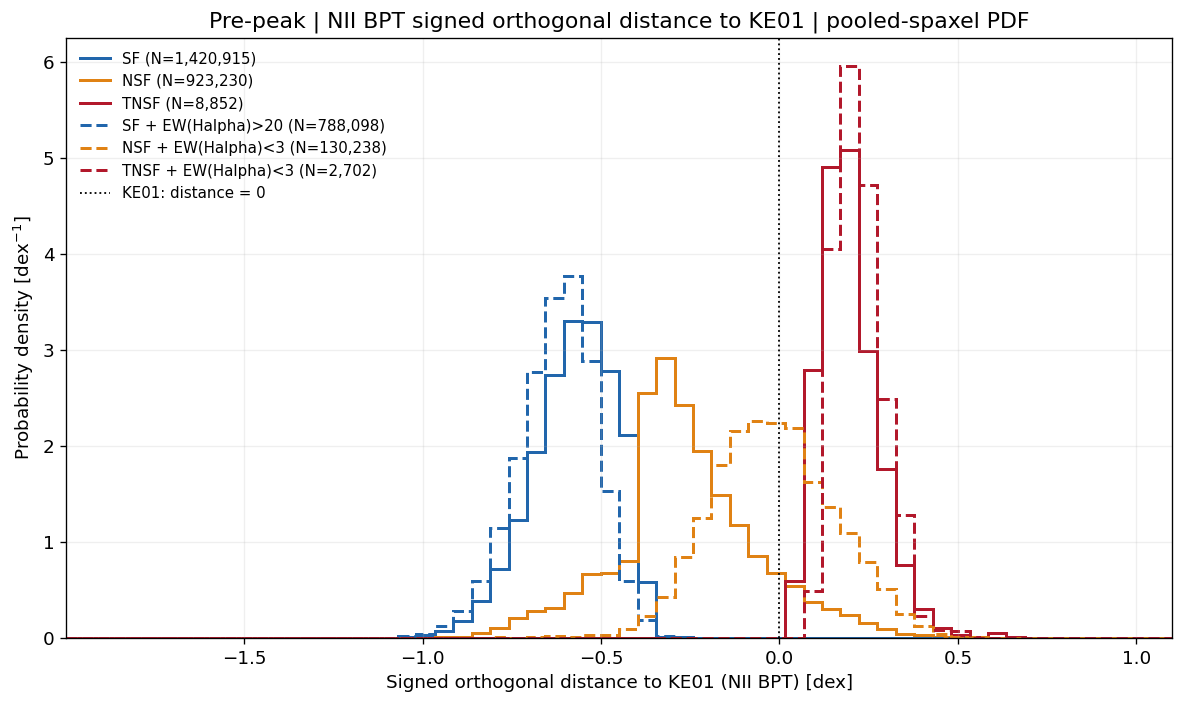

In [7]:
plot_stage_pdf("pre-peak", "NII")


Close-to-peak | NII | ranges and medians of plotted data
SF: N=720,842; galaxies=5; signed distance range=[-1.04983, -0.25463] dex; median=-0.559059 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF: N=486,897; galaxies=5; signed distance range=[-1.19367, 0.742703] dex; median=-0.266859 dex; negative=88.4226%; positive=11.5774%; zero=0.0000%
TNSF: N=6,217; galaxies=5; signed distance range=[0.0362352, 0.70482] dex; median=0.200701 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%
SF + EW(Halpha)>20: N=292,542; galaxies=5; signed distance range=[-1.04983, -0.25463] dex; median=-0.62392 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF + EW(Halpha)<3: N=95,976; galaxies=5; signed distance range=[-1.07657, 0.742703] dex; median=-0.014182 dex; negative=53.0966%; positive=46.9034%; zero=0.0000%
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; signed distance range=[0.107591, 0.634725] dex; median=0.247059 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%


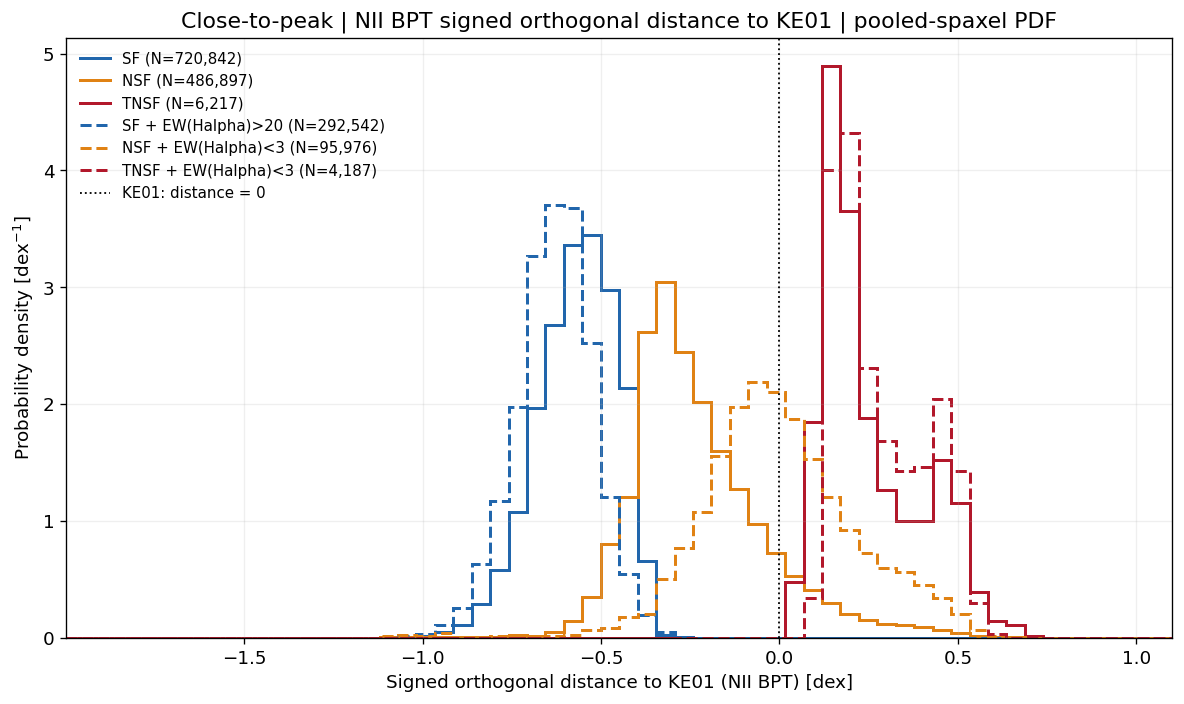

In [8]:
plot_stage_pdf("close-to-peak", "NII")


Post-peak | NII | ranges and medians of plotted data
SF: N=222,427; galaxies=13; signed distance range=[-1.28782, -0.327797] dex; median=-0.604815 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF: N=810,973; galaxies=13; signed distance range=[-1.99994, 1.10146] dex; median=0.0269977 dex; negative=46.2753%; positive=53.7247%; zero=0.0000%
TNSF: N=94,780; galaxies=13; signed distance range=[0.0157631, 0.915949] dex; median=0.230163 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%
SF + EW(Halpha)>20: N=61,662; galaxies=13; signed distance range=[-1.28782, -0.342789] dex; median=-0.713477 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF + EW(Halpha)<3: N=497,797; galaxies=13; signed distance range=[-1.80608, 1.10146] dex; median=0.128376 dex; negative=25.8093%; positive=74.1907%; zero=0.0000%
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; signed distance range=[0.0628733, 0.741534] dex; median=0.240379 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%


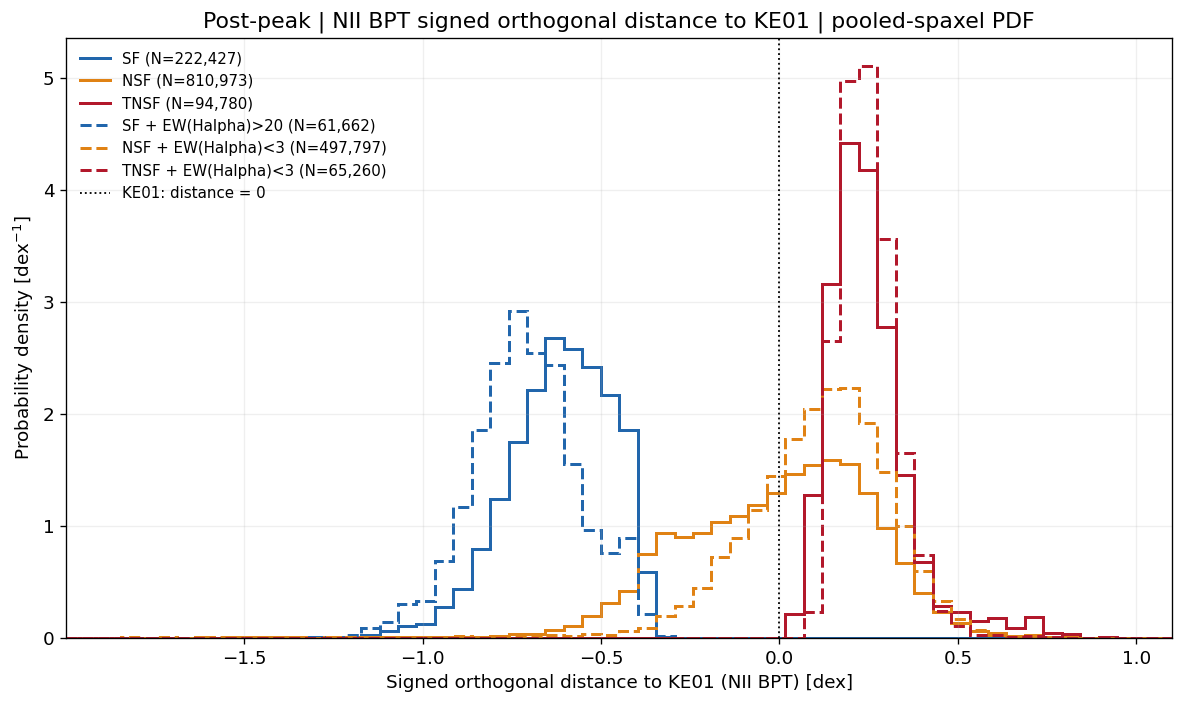

In [9]:
plot_stage_pdf("post-peak", "NII")

## SII BPT: distance to KE01

Pre-peak, close-to-peak and post-peak PDFs, in that order.


Pre-peak | SII | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; signed distance range=[-1.23076, -0.00709875] dex; median=-0.441576 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF: N=923,217; galaxies=8; signed distance range=[-1.37401, 0.686265] dex; median=-0.122681 dex; negative=78.6002%; positive=21.3998%; zero=0.0000%
TNSF: N=8,852; galaxies=5; signed distance range=[0.0252193, 0.501186] dex; median=0.195622 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%
SF + EW(Halpha)>20: N=788,098; galaxies=8; signed distance range=[-1.23076, -0.00709875] dex; median=-0.513459 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF + EW(Halpha)<3: N=130,225; galaxies=5; signed distance range=[-0.680388, 0.686265] dex; median=-0.00988928 dex; negative=53.5189%; positive=46.4811%; zero=0.0000%
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; signed distance range=[0.0904604, 0.392387] dex; median=0.209471 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%


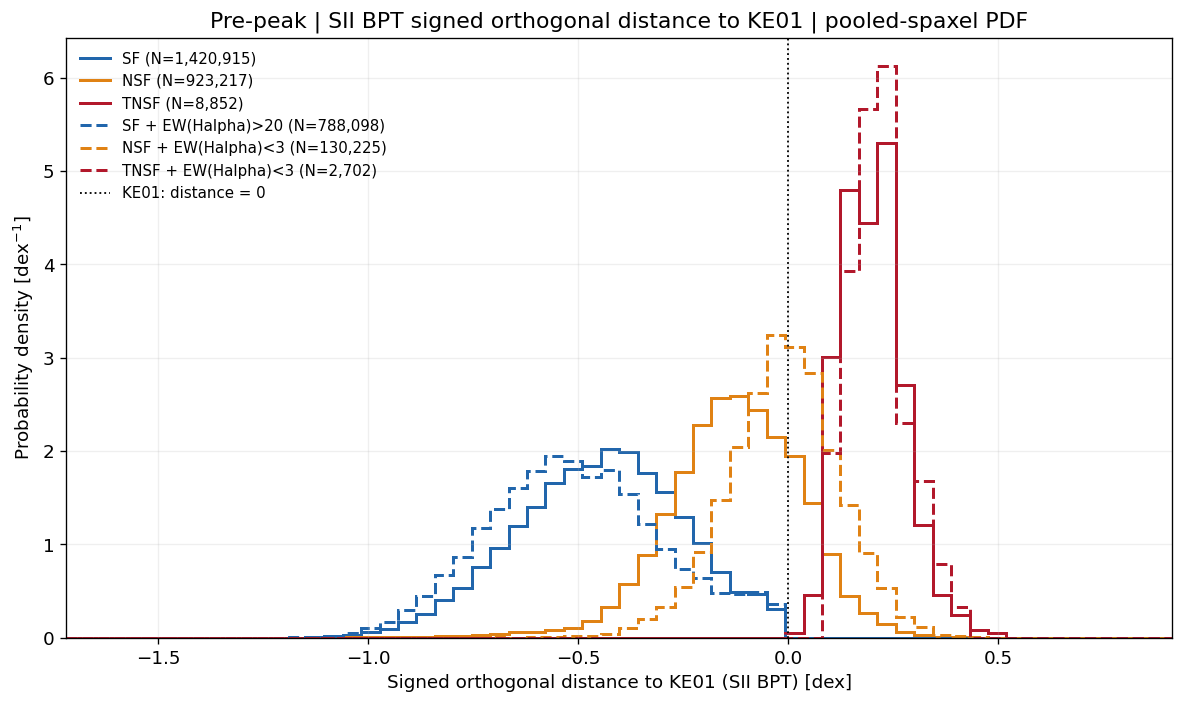

In [10]:
plot_stage_pdf("pre-peak", "SII")


Close-to-peak | SII | ranges and medians of plotted data
SF: N=720,842; galaxies=5; signed distance range=[-1.17398, -0.0146464] dex; median=-0.383374 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF: N=486,631; galaxies=5; signed distance range=[-1.71894, 0.705389] dex; median=-0.0503123 dex; negative=62.1660%; positive=37.8340%; zero=0.0000%
TNSF: N=6,217; galaxies=5; signed distance range=[0.0419266, 0.617605] dex; median=0.25968 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%
SF + EW(Halpha)>20: N=292,542; galaxies=5; signed distance range=[-1.17398, -0.0146464] dex; median=-0.448854 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF + EW(Halpha)<3: N=95,710; galaxies=5; signed distance range=[-1.71894, 0.705389] dex; median=0.102834 dex; negative=24.8532%; positive=75.1468%; zero=0.0000%
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; signed distance range=[0.10202, 0.617605] dex; median=0.265854 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%


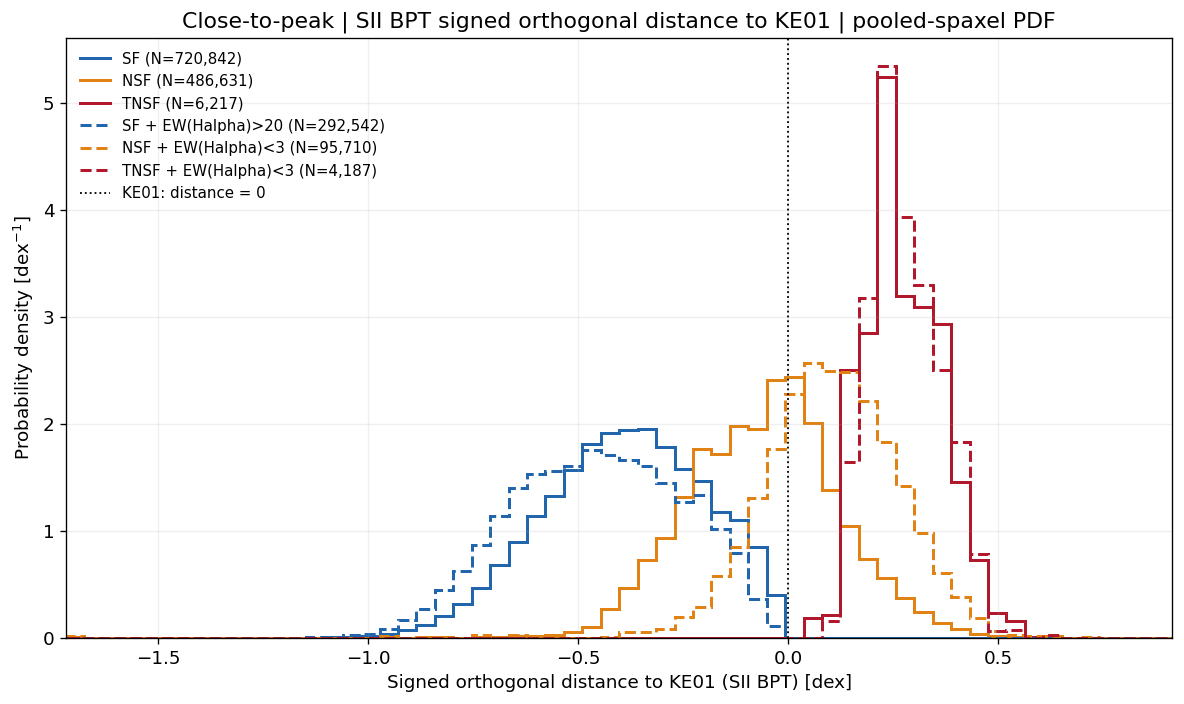

In [11]:
plot_stage_pdf("close-to-peak", "SII")


Post-peak | SII | ranges and medians of plotted data
SF: N=222,427; galaxies=13; signed distance range=[-1.22784, -0.137133] dex; median=-0.560214 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF: N=806,315; galaxies=13; signed distance range=[-1.64777, 0.913879] dex; median=0.0818826 dex; negative=39.1276%; positive=60.8724%; zero=0.0000%
TNSF: N=94,780; galaxies=13; signed distance range=[0.0164423, 0.744204] dex; median=0.310404 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%
SF + EW(Halpha)>20: N=61,662; galaxies=13; signed distance range=[-1.22784, -0.202741] dex; median=-0.689449 dex; negative=100.0000%; positive=0.0000%; zero=0.0000%
NSF + EW(Halpha)<3: N=493,821; galaxies=13; signed distance range=[-1.55517, 0.913879] dex; median=0.172343 dex; negative=20.6532%; positive=79.3468%; zero=0.0000%
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; signed distance range=[0.0825595, 0.719829] dex; median=0.325503 dex; negative=0.0000%; positive=100.0000%; zero=0.0000%


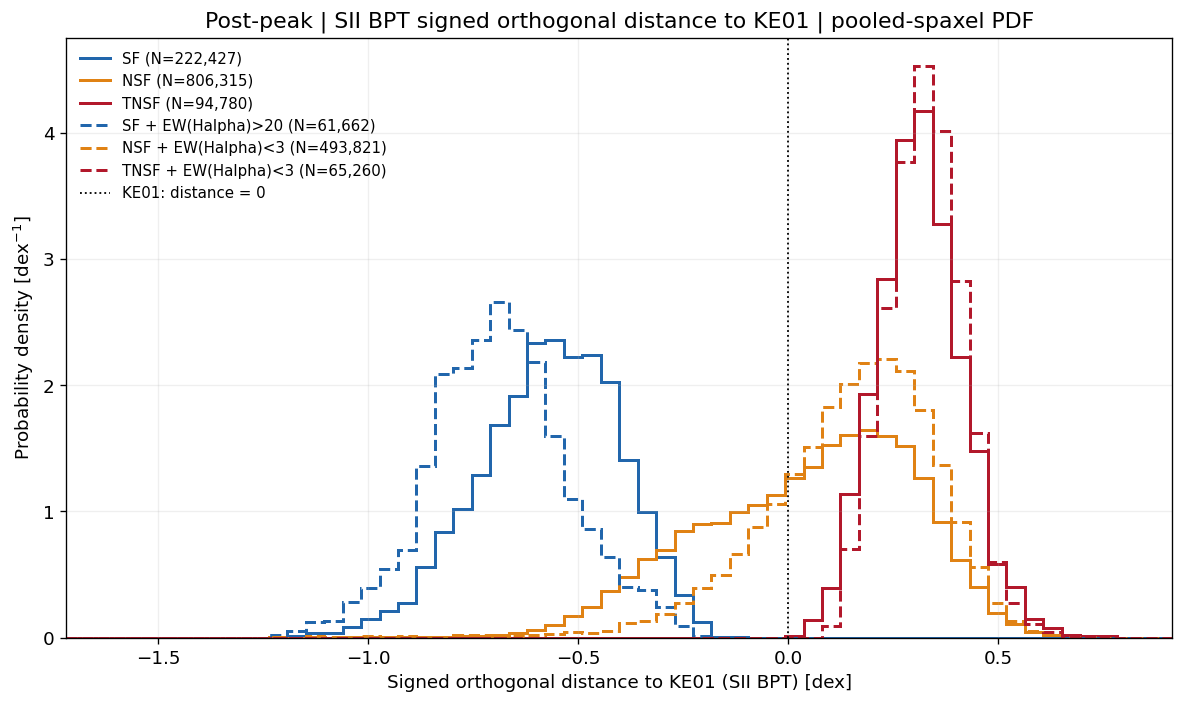

In [12]:
plot_stage_pdf("post-peak", "SII")

## Numerical summary and verification

Signed distances, sign fractions and PDF integrals for all 36 stage/diagram/region combinations. Projection QC reports the original spaxel counts and unique coordinate counts; deduplication is computational only.

In [13]:
PDF_SUMMARY = pd.DataFrame(PDF_SUMMARY_ROWS)
assert len(PDF_SUMMARY) == len(STAGE_ORDER) * len(OBSERVABLE_ORDER) * len(CATEGORY_ORDER)
assert not PDF_SUMMARY.duplicated(["stage", "diagram", "category"]).any()
assert all(HISTOGRAM_CHECKS)
nonempty = PDF_SUMMARY.N_spaxel.gt(0)
assert np.allclose(PDF_SUMMARY.loc[nonempty, "PDF_integral"], 1)
assert np.allclose(PDF_SUMMARY.loc[nonempty, ["fraction_negative", "fraction_positive", "fraction_zero"]].sum(axis=1), 1)
assert (MEASUREMENT_COUNTS.N_finite <= MEASUREMENT_COUNTS.N_selected).all()
assert MEASUREMENT_COUNTS.N_selected.eq(MEASUREMENT_COUNTS.N_finite + MEASUREMENT_COUNTS.N_unavailable).all()
assert MEASUREMENT_COUNTS.groupby(["GALID", "category"]).N_selected.nunique().eq(1).all()
assert (PDF_SUMMARY.loc[nonempty, "distance_min_dex"] <= PDF_SUMMARY.loc[nonempty, "distance_median_dex"]).all()
assert (PDF_SUMMARY.loc[nonempty, "distance_median_dex"] <= PDF_SUMMARY.loc[nonempty, "distance_max_dex"]).all()
assert PROJECTION_QC.max_orthogonality_residual.lt(1e-8).all()
display(PDF_SUMMARY)
print("KE01_ORTHOGONAL_DISTANCE_PDF_VALIDATION_OK: NII then SII; 6 figures; 36 distributions")


,stage,diagram,category,N_spaxel,N_galaxies,distance_min_dex,distance_max_dex,distance_median_dex,fraction_negative,fraction_positive,fraction_zero,PDF_integral
0,pre-peak,NII,SF,1420915,8,-1.115648,-0.222761,-0.566365,1.000000,0.000000,0.0,1.0
1,pre-peak,NII,NSF,923230,8,-1.281907,0.673442,-0.281549,0.898503,0.101497,0.0,1.0
2,pre-peak,NII,TNSF,8852,5,0.040222,0.673442,0.184696,0.000000,1.000000,0.0,1.0
3,pre-peak,NII,SF + EW(Halpha)>20,788098,8,-1.115648,-0.222761,-0.614167,1.000000,0.000000,0.0,1.0
4,pre-peak,NII,NSF + EW(Halpha)<3,130238,5,-0.768028,0.647383,-0.023164,0.555997,0.444003,0.0,1.0
5,pre-peak,NII,TNSF + EW(Halpha)<3,2702,4,0.100524,0.484064,0.213441,0.000000,1.000000,0.0,1.0
6,close-to-peak,NII,SF,720842,5,-1.049832,-0.254630,-0.559059,1.000000,0.000000,0.0,1.0
7,close-to-peak,NII,NSF,486897,5,-1.193668,0.742703,-0.266859,0.884226,0.115774,0.0,1.0
8,close-to-peak,NII,TNSF,6217,5,0.036235,0.704820,0.200701,0.000000,1.000000,0.0,1.0
9,close-to-peak,NII,SF + EW(Halpha)>20,292542,5,-1.049832,-0.254630,-0.623920,1.000000,0.000000,0.0,1.0


KE01_ORTHOGONAL_DISTANCE_PDF_VALIDATION_OK: NII then SII; 6 figures; 36 distributions


## All six distance PDFs together

Three rows: pre-peak, close-to-peak, post-peak. Two columns: NII, SII. Reuse the same full-range bins, six region selections and styles as the individual plots. All panels share a probability-density scale; x limits are shared within each BPT column.


Pre-peak | NII | combined PDF
SF: N=1,420,915; distance range=[-1.11565, -0.222761] dex; median=-0.566365 dex; PDF integral=1
NSF: N=923,230; distance range=[-1.28191, 0.673442] dex; median=-0.281549 dex; PDF integral=1
TNSF: N=8,852; distance range=[0.0402216, 0.673442] dex; median=0.184696 dex; PDF integral=1
SF + EW(Halpha)>20: N=788,098; distance range=[-1.11565, -0.222761] dex; median=-0.614167 dex; PDF integral=1
NSF + EW(Halpha)<3: N=130,238; distance range=[-0.768028, 0.647383] dex; median=-0.0231645 dex; PDF integral=1
TNSF + EW(Halpha)<3: N=2,702; distance range=[0.100524, 0.484064] dex; median=0.213441 dex; PDF integral=1

Pre-peak | SII | combined PDF
SF: N=1,420,915; distance range=[-1.23076, -0.00709875] dex; median=-0.441576 dex; PDF integral=1
NSF: N=923,217; distance range=[-1.37401, 0.686265] dex; median=-0.122681 dex; PDF integral=1
TNSF: N=8,852; distance range=[0.0252193, 0.501186] dex; median=0.195622 dex; PDF integral=1
SF + EW(Halpha)>20: N=788,098; distance ra

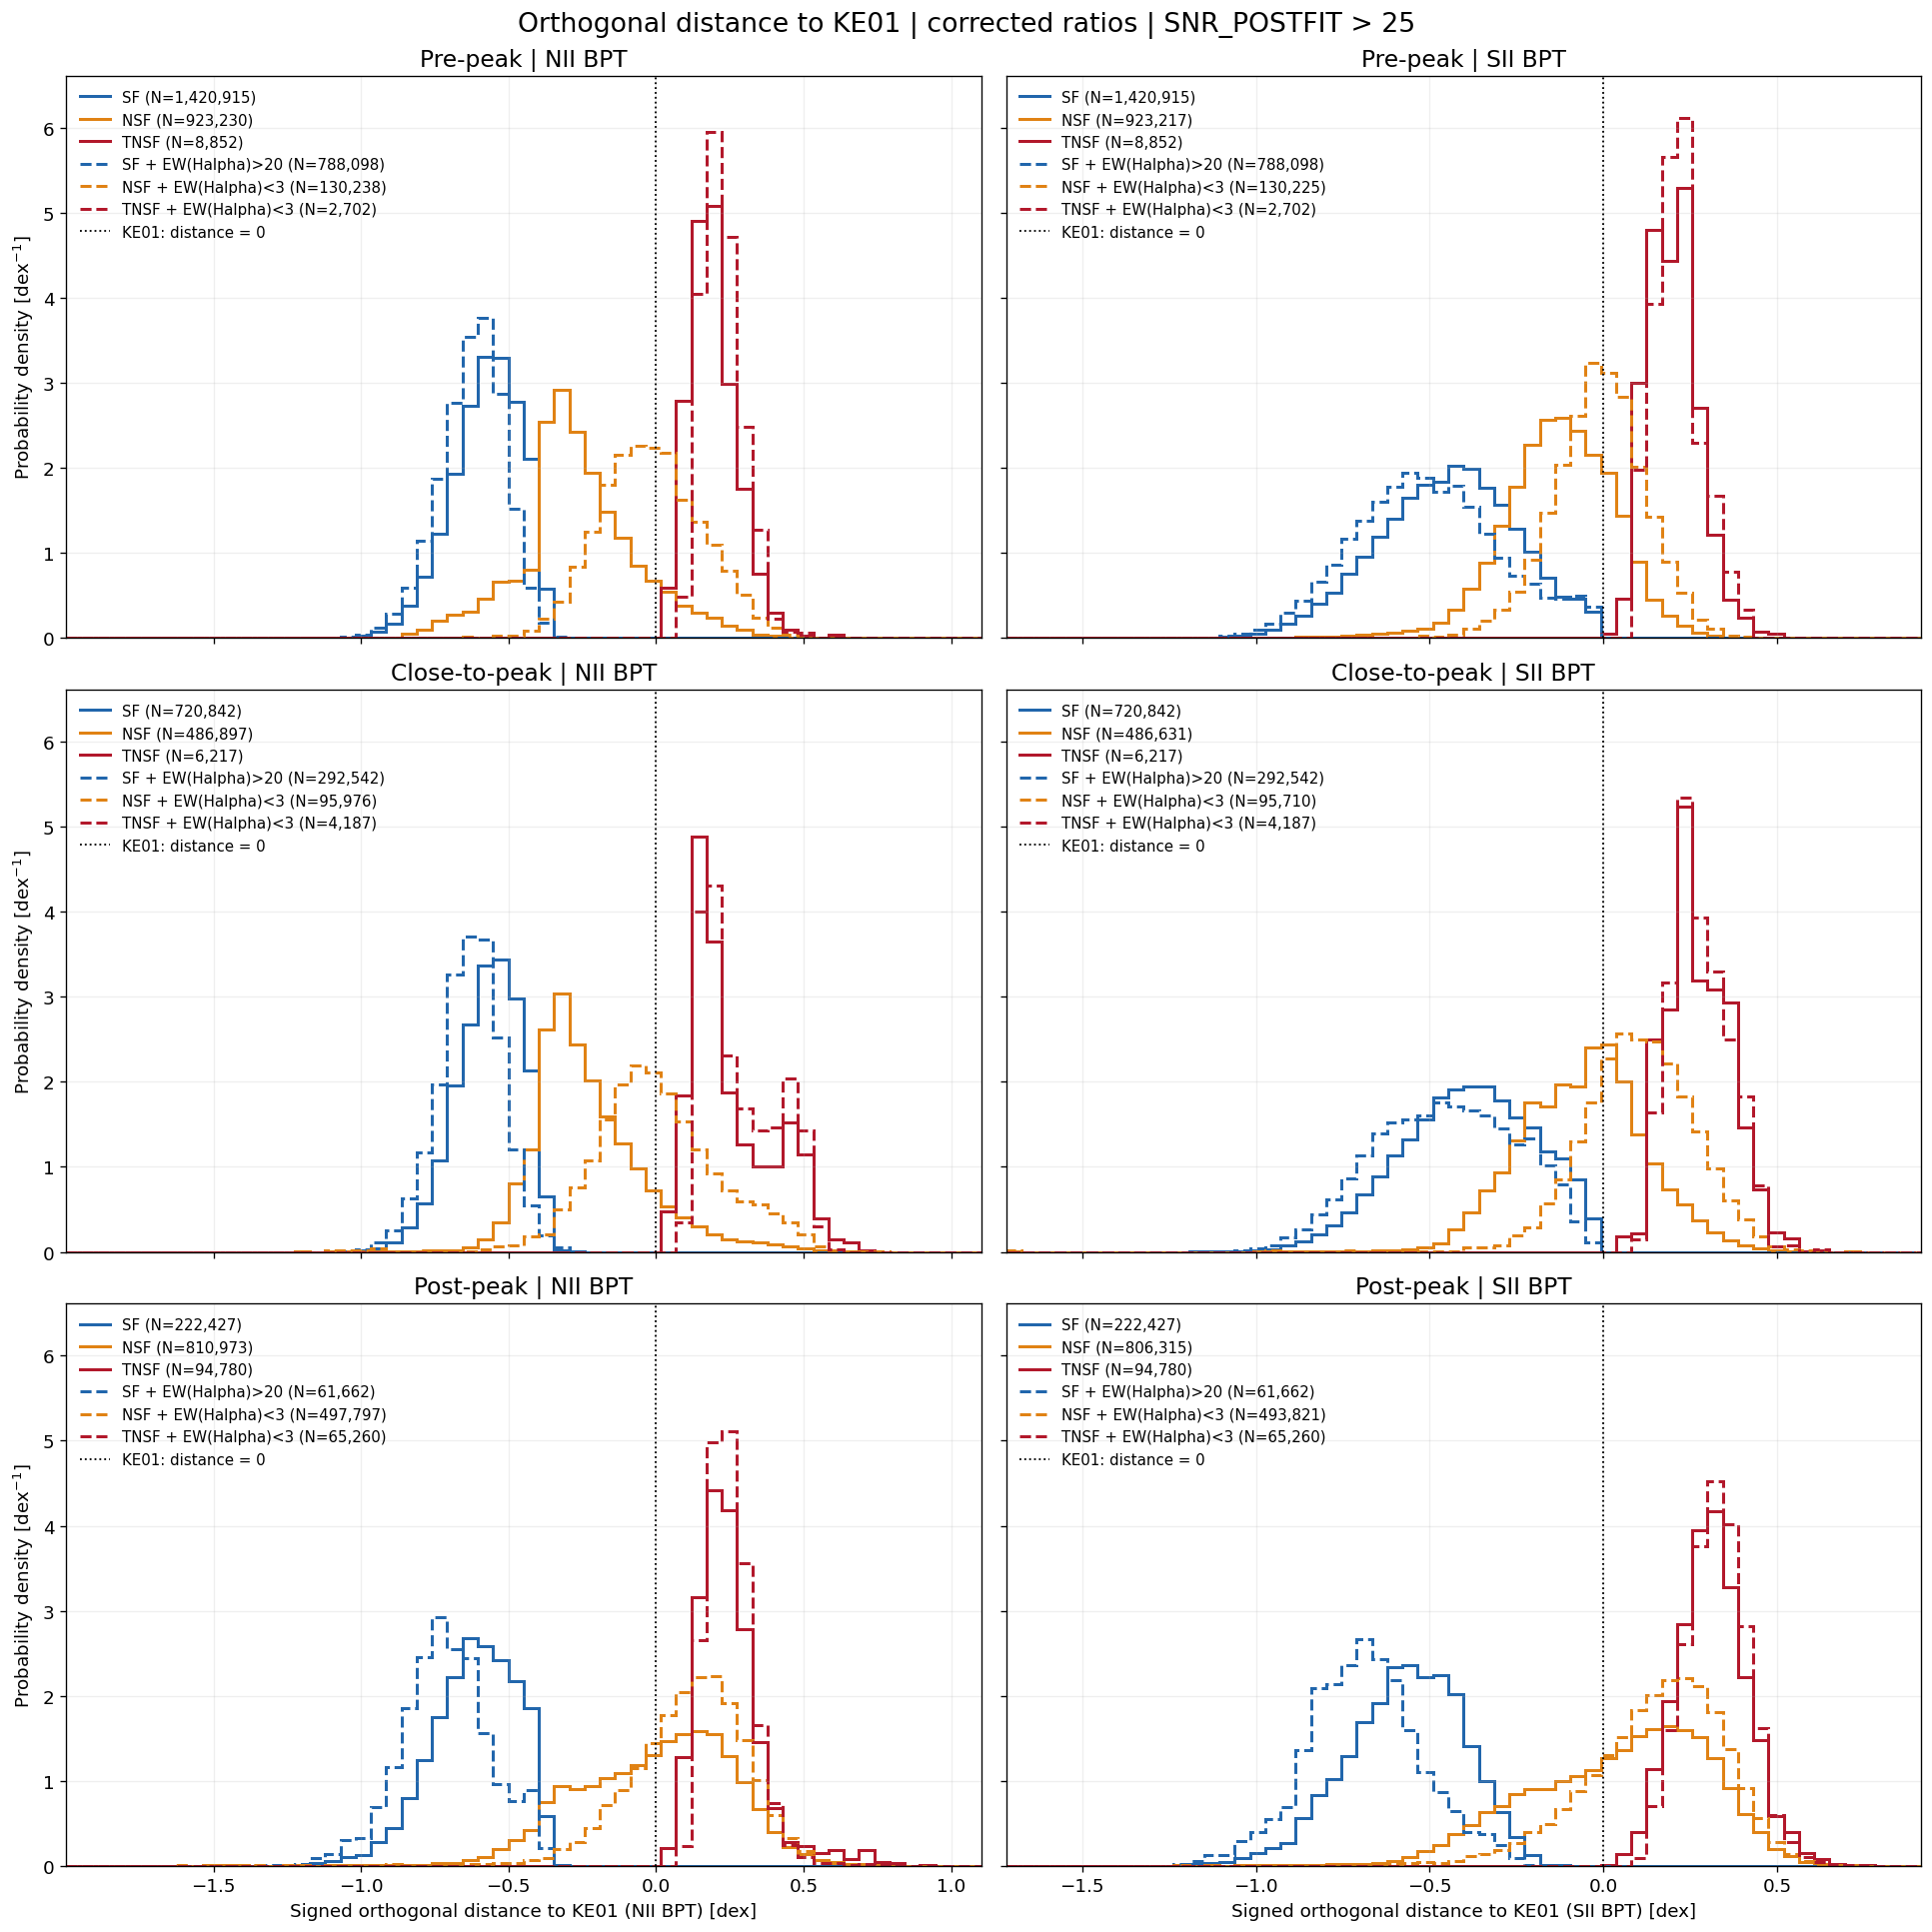

COMBINED_KE01_DISTANCE_PDF_VALIDATION_OK: 3 rows x 2 columns; 36 distributions


In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16), sharex="col", sharey=True, layout="constrained")
combined_checks = []
combined_max_density = 0.0
for i, stage in enumerate(STAGE_ORDER):
    for j, diagram in enumerate(OBSERVABLE_ORDER):
        ax = axes[i, j]
        edges = COMMON_EDGES[diagram]
        print(f"\n{STAGE_LABELS[stage]} | {diagram} | combined PDF")
        for category in CATEGORY_ORDER:
            values = POOLED[stage, diagram, category]
            if values.size:
                counts, _ = np.histogram(values, bins=edges)
                density = counts / (values.size * np.diff(edges))
                integral = float(np.sum(density * np.diff(edges)))
                assert counts.sum() == values.size
                assert np.isclose(integral, 1.0)
                combined_max_density = max(combined_max_density, float(density.max()))
                print(f"{category}: N={values.size:,}; distance range=[{values.min():.6g}, {values.max():.6g}] dex; "
                      f"median={np.median(values):.6g} dex; PDF integral={integral:.6g}")
                ax.stairs(density, edges, color=CATEGORY_COLORS[category], linestyle=CATEGORY_STYLES[category],
                          linewidth=1.8, label=f"{category} (N={values.size:,})")
            else:
                print(f"{category}: N=0; no finite paired distances")
                ax.plot([], [], color=CATEGORY_COLORS[category], linestyle=CATEGORY_STYLES[category],
                        label=category + " (N=0)")
            combined_checks.append(True)
        ax.axvline(0.0, color="black", linewidth=1.1, linestyle=":", label="KE01: distance = 0")
        ax.set_xlim(min(edges[0], 0.0), max(edges[-1], 0.0))
        ax.set_title(f"{STAGE_LABELS[stage]} | {diagram} BPT", fontsize=14)
        if i == len(STAGE_ORDER) - 1:
            ax.set_xlabel(OBSERVABLE_LABELS[diagram])
        if j == 0:
            ax.set_ylabel("Probability density [dex$^{-1}$]")
        ax.legend(frameon=False, fontsize=9, loc="best")
        ax.grid(alpha=0.2)
axes[0, 0].set_ylim(0, max(1.0, combined_max_density * 1.08))
fig.suptitle("Orthogonal distance to KE01 | corrected ratios | SNR_POSTFIT > 25", fontsize=16)
assert axes.shape == (3, 2)
assert len(combined_checks) == len(STAGE_ORDER) * len(OBSERVABLE_ORDER) * len(CATEGORY_ORDER)
assert all(combined_checks)
plt.show()
plt.close(fig)
print("COMBINED_KE01_DISTANCE_PDF_VALIDATION_OK: 3 rows x 2 columns; 36 distributions")
